In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

conn = duckdb.connect('../ecommerce.db')

df = conn.execute("""
    SELECT
        c.customer_id,
        c.customer_name,
        c.acquisition_channel,
        c.city,
        l.total_orders,
        l.completed_orders,
        l.total_revenue,
        l.avg_order_value,
        l.first_order_date,
        l.last_order_date,
        l.signup_date
    FROM analytics.mart_customer_lifetime l
    JOIN analytics.stg_customers c ON l.customer_id = c.customer_id
    WHERE l.completed_orders > 0
""").df()

conn.close()

for col in ['first_order_date', 'last_order_date', 'signup_date']:
    df[col] = pd.to_datetime(df[col])

print(f"Loaded {len(df)} customers")
df.head()

Loaded 1901 customers


,customer_id,customer_name,acquisition_channel,city,total_orders,completed_orders,total_revenue,avg_order_value,first_order_date,last_order_date,signup_date
0,C0001,Aryan Maharaj,organic,Jaipur,4,3,14036.24,4678.75,2023-07-30,2024-06-30,2023-07-29
1,C0002,Gagan Sami,referral,Kolkata,3,2,7685.89,3842.95,2024-02-24,2024-06-30,2023-08-22
2,C0003,Yashasvi Bala,organic,Pune,4,3,11264.24,3754.75,2023-04-03,2024-06-30,2023-02-13
3,C0004,Abeer Dutta,paid_search,Jaipur,5,4,15971.54,3992.89,2022-08-09,2024-04-11,2022-05-22
4,C0005,Gayathri Chaudry,referral,Mumbai,6,5,30780.75,6156.15,2024-03-09,2024-06-30,2024-02-13


In [2]:
snapshot_date = pd.Timestamp('2024-07-01')

# Churned = no order in last 90 days
df['days_since_last_order'] = (snapshot_date - df['last_order_date']).dt.days
df['churned'] = (df['days_since_last_order'] > 90).astype(int)

# Feature engineering
df['days_since_signup']   = (snapshot_date - df['signup_date']).dt.days
df['order_rate']          = df['completed_orders'] / (df['days_since_signup'] / 30)
df['return_rate']         = (df['total_orders'] - df['completed_orders']) / df['total_orders'].replace(0, 1)
df['avg_order_value']     = df['avg_order_value'].fillna(0)

# Encode acquisition channel
channel_dummies = pd.get_dummies(df['acquisition_channel'], prefix='channel', drop_first=True)
df = pd.concat([df, channel_dummies], axis=1)

print(f"Churned customers : {df['churned'].sum()} ({df['churned'].mean()*100:.1f}%)")
print(f"Active customers  : {(df['churned']==0).sum()} ({(1-df['churned'].mean())*100:.1f}%)")

Churned customers : 453 (23.8%)
Active customers  : 1448 (76.2%)


In [3]:
feature_cols = [
    'completed_orders',
    'total_revenue',
    'avg_order_value',
    'days_since_signup',
    'days_since_last_order',
    'order_rate',
    'return_rate',
] + [c for c in df.columns if c.startswith('channel_')]

X = df[feature_cols].fillna(0)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       0.99      0.99      0.99        91

    accuracy                           0.99       381
   macro avg       0.99      0.99      0.99       381
weighted avg       0.99      0.99      0.99       381

AUC-ROC Score: 1.000


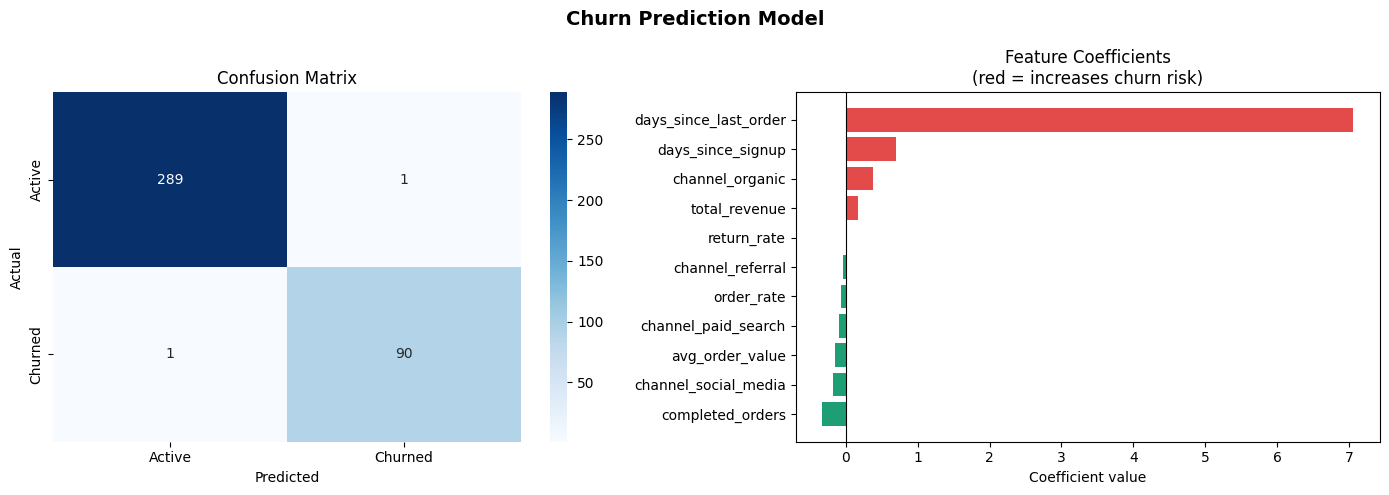

Chart saved to reports/churn_model.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Prediction Model', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Feature importance
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

colors = ['#E24B4A' if c > 0 else '#1D9E75' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\n(red = increases churn risk)')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('../reports/churn_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/churn_model.png")

In [5]:
df['churn_probability'] = model.predict_proba(scaler.transform(X.fillna(0)))[:, 1]
df['churn_label']       = (df['churn_probability'] > 0.5).astype(int)

conn = duckdb.connect('../ecommerce.db')

conn.execute("DROP TABLE IF EXISTS analytics.mart_churn_predictions")
conn.execute("""
    CREATE TABLE analytics.mart_churn_predictions AS
    SELECT
        customer_id,
        customer_name,
        city,
        acquisition_channel,
        completed_orders,
        total_revenue,
        days_since_last_order,
        ROUND(churn_probability, 4) AS churn_probability,
        churn_label,
        CASE
            WHEN churn_probability >= 0.75 THEN 'High'
            WHEN churn_probability >= 0.50 THEN 'Medium'
            ELSE 'Low'
        END AS churn_risk
    FROM df
""")

print("Churn risk breakdown:")
print(conn.execute("""
    SELECT churn_risk,
           COUNT(*) as customers,
           ROUND(AVG(total_revenue), 2) as avg_revenue
    FROM analytics.mart_churn_predictions
    GROUP BY churn_risk
    ORDER BY customers DESC
""").df().to_string(index=False))

conn.close()
print("\nSaved to analytics.mart_churn_predictions")

Churn risk breakdown:
churn_risk  customers  avg_revenue
       Low       1447     12690.77
      High        421     11715.74
    Medium         33     15019.64

Saved to analytics.mart_churn_predictions
